# MLIA PS3 Solution
### By Sravanth Chowdary Potluri und5uv


### Question 1



# Bayesian Logistic Regression for Binary Image Classification

Given a dataset $(X, Y)$ where $ X \in \mathbb{R}^d $ and $ Y \in \{0, 1\} $, we aim to train a Bayesian logistic regression model to classify a new data point $\tilde{x}$ by predicting its unknown label $\tilde{y}$.

Our model setup includes:
1. **Likelihood**: $ Y \sim \text{Bernoulli} \left( \frac{1}{1 + e^{-X^T \beta}} \right) $
2. **Prior on Coefficients**: $ \beta \sim \mathcal{N}(0, \sigma^2 I) $, where $ I $ is the identity matrix.

The objective is to perform Bayesian inference on the coefficient vector $ \beta $.

### (a) Deriving the Unnormalized Posterior $ p(\beta | Y) $

The unnormalized posterior $ p(\beta | Y) $ is given by Bayes' theorem as:

$$
p(\beta | y; x, \sigma) \propto \prod_{i=1}^n p(y_i | \beta; x_i) \, p(\beta; \sigma)
$$

Given:
- **Likelihood**: $ p(y_i | \beta; x_i) = \frac{1}{1 + e^{-x_i^\top \beta}} $ for $ y_i = 1 $, and $ \frac{e^{-x_i^\top \beta}}{1 + e^{-x_i^\top \beta}} $ for $ y_i = 0 $, Since the likelihood is given as a Bernoulli distribution of a sigmoid function.
- **Prior**: $ p(\beta; \sigma) \sim e^{-\frac{1}{2\sigma^2} \|\beta\|^2} $, Prior on coefficients is a Normal distribution.

we have:

$$
p(\beta | y; x, \sigma) \propto \prod_{i=1}^n \left( \frac{1}{1 + e^{-x_i^\top \beta}} \right)^{y_i} \left( \frac{e^{-x_i^\top \beta}}{1 + e^{-x_i^\top \beta}} \right)^{1 - y_i} \times e^{-\frac{1}{2\sigma^2} \|\beta\|^2}
$$

Simplifying, we get:

$$
p(\beta | y; x, \sigma) \propto \prod_{i=1}^n \frac{e^{(1 - y_i)x_i^\top \beta}}{1 + e^{x_i^\top \beta}} \times e^{-\frac{1}{2\sigma^2} \|\beta\|^2}
$$

This is the unnormalized posterior $ p(\beta | Y) $.



### (b) Expressing the Posterior in Terms of $ \exp(-U(\beta)) $

To express the posterior in the form $ p(\beta | y; x, \sigma) \propto \exp(-U(\beta)) $, we take the logarithm on both sides of the unnormalized posterior, Taking logarithm might be mathematically incorrect for the proportionality, but we do not care about the proportionality constant because we are just interested in optimization and the expression we have is good enough for that.

$$
\log p(\beta | y; x, \sigma) \propto \sum_{i=1}^n \left( y_i \left( -\log(1 + e^{-x_i^\top \beta}) \right) + (1 - y_i) \left( -x_i^\top \beta - \log(1 + e^{-x_i^\top \beta}) \right) \right) - \frac{1}{2\sigma^2} \|\beta\|^2
$$

By Rearranging terms and Simplifying this expression:

$$
\log p(\beta | y; x, \sigma) \propto -\sum_{i=1}^n \left( (1 - y_i) x_i^\top \beta + \log(1 + e^{-x_i^\top \beta}) \right) - \frac{1}{2\sigma^2} \|\beta\|^2
$$

Therefore, we have:

$$
p(\beta | y; x, \sigma) \propto \exp\left( -U(\beta) \right)
$$

where:

$$
U(\beta) = \sum_{i=1}^n \left( (1 - y_i) x_i^\top \beta + \log(1 + e^{-x_i^\top \beta}) \right) + \frac{1}{2\sigma^2} \|\beta\|^2
$$

### (c) Maximum A Posteriori (MAP) Estimation for $ \beta $

To find the MAP estimator for $ \beta $, we aim to minimize $ U(\beta) $.

#### Gradient of $ U(\beta) $

Using the sigmoid function $ \sigma(z) = \frac{1}{1 + e^{-z}} $, we compute the gradient of $ U(\beta) $ with respect to $ \beta $, We get an expression for the gradient as:

$$
\nabla U(\beta) = \sum_{i=1}^n \left( (1 - y_i) x_i - \frac{e^{-x_i^\top \beta}}{1 + e^{-x_i^\top \beta}} x_i \right) + \frac{1}{\sigma^2} \beta
$$

which simplifies when we use the sigmoid function to:

$$
\nabla U(\beta) = \sum_{i=1}^n \left( \left( \sigma(x_i^\top \beta) - y_i \right) x_i \right) + \frac{1}{\sigma^2} \beta
$$

#### Gradient Descent Algorithm

To perform MAP estimation, we can use gradient descent optimization method to minimize $ U(\beta) $:

1. **Initialize** $ \beta^{(0)} $, for example, with zeros.
2. **Repeat** until convergence:
   - Compute the gradient $ \nabla U(\beta^{(k)}) $.
   - Update $ \beta $ using:
     $$
     \beta^{(k+1)} = \beta^{(k)} - \epsilon \nabla U(\beta^{(k)})
     $$
   - Here, $ \epsilon $ is the step size/learning rate.

The result is an estimated value of $ \beta $ that maximizes the posterior distribution, thus providing the MAP estimate.

reference : https://machinelearningmastery.com/maximum-a-posteriori-estimation/

### (d)

In [22]:
# importing the required libraries
import numpy as np
import pandas as pd

In [23]:
X_train = np.array(pd.read_csv("PS3-24/data-mnist/trainX.txt"))
X_test =  np.array(pd.read_csv("PS3-24/data-mnist/testX.txt"))
y_train = np.array(pd.read_csv("PS3-24/data-mnist/trainY.txt"))
y_test = np.array(pd.read_csv("PS3-24/data-mnist/testY.txt"))

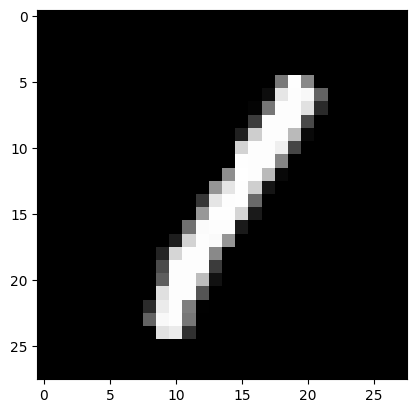

In [24]:
# display an image from X_train
import matplotlib.pyplot as plt
plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.show()

In [25]:
# **(d) Analyzing the MNIST Dataset (Digits "0" and "1")**

# Extract digits "0" and "1" from training data
train_filter = (y_train == 0) | (y_train == 1)
X_train_01 = X_train[train_filter.flatten()]
y_train_01 = y_train[train_filter].flatten()

# Extract digits "0" and "1" from test data
test_filter = (y_test == 0) | (y_test == 1)
X_test_01 = X_test[test_filter.flatten()]
y_test_01 = y_test[test_filter].flatten()

# Add intercept term (column of ones)
X_train_01 = np.hstack((np.ones((X_train_01.shape[0], 1)), X_train_01))
X_test_01 = np.hstack((np.ones((X_test_01.shape[0], 1)), X_test_01))

In [26]:
# displaying shapes of the 01 data
print(X_train_01.shape)
print(y_train_01.shape)
print(X_test_01.shape)
print(y_test_01.shape)

(84, 785)
(84,)
(114, 785)
(114,)


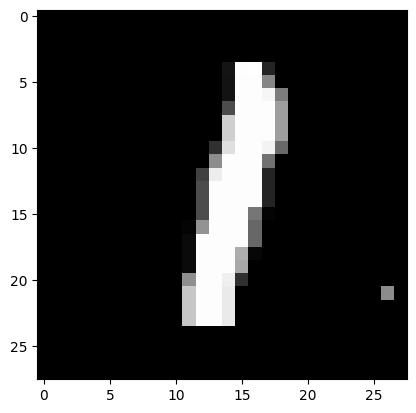

In [27]:
# display an image from X_train_01
plt.imshow(X_train_01[10][1:].reshape(28,28), cmap='gray')
plt.show()

So basically, there are 84 training images and 114 test images of digits 0 and 1.

Iteration 1: Completed
Iteration 2: Completed
Iteration 3: Completed
Iteration 4: Completed
Iteration 5: Completed
Iteration 6: Completed
Iteration 7: Completed
Iteration 8: Completed
Iteration 9: Completed
Iteration 10: Completed
Iteration 11: Completed
Iteration 12: Completed
Iteration 13: Completed
Iteration 14: Completed
Iteration 15: Completed
Iteration 16: Completed
Iteration 17: Completed
Iteration 18: Completed
Iteration 19: Completed
Iteration 20: Completed


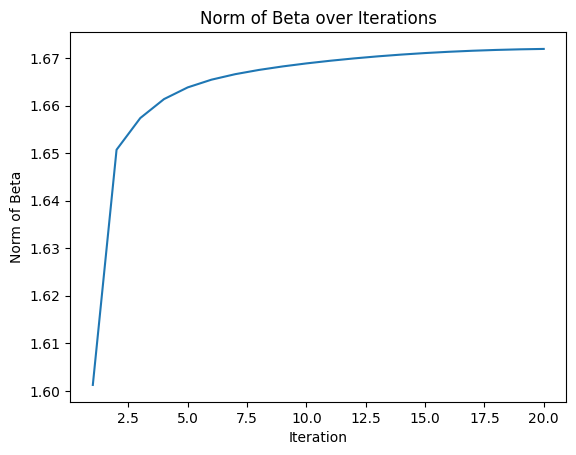

In [28]:
# **(c) Implementing MAP Estimation**

# Initialize beta to zeros initially
beta = np.zeros(X_train_01.shape[1])

# Set hyperparameters
sigma = 1.0         # Prior variance
epsilon = 0.01      # Step size for gradient descent
num_iterations = 20  # Number of iterations

beta_norm_list = []

# Gradient Descent for MAP Estimation
for iteration in range(num_iterations):
    # Compute the linear combination
    z = X_train_01.dot(beta)
    # Compute the sigmoid function
    y_pred = 1 / (1 + np.exp(-z))
    # Compute the gradient
    gradient = X_train_01.T.dot(y_pred - y_train_01) + beta / sigma**2
    # Update beta
    beta -= epsilon * gradient
    print(f"Iteration {iteration + 1}: Completed")
    # Calculate the norm of beta
    beta_norm = np.linalg.norm(beta)
    beta_norm_list.append(beta_norm)


# Plot the norm of beta over iterations
plt.plot(range(1, num_iterations + 1), beta_norm_list)
plt.xlabel("Iteration")
plt.ylabel("Norm of Beta")
plt.title("Norm of Beta over Iterations")
plt.show()

### Here you can see that the plot of beta norm is plateauing, This shows that the model is converging to a solution.

In [29]:
# **(e) Prediction and Zero-One Loss Calculation**

# Prediction on test data
z_test = X_test_01.dot(beta)
y_pred_test_prob = 1 / (1 + np.exp(-z_test))
# Convert probabilities to binary predictions (0 or 1) by thresholding at 0.5
y_pred_test = (y_pred_test_prob >= 0.5).astype(int)

# Calculate zero-one loss using scikit-learn
from sklearn.metrics import zero_one_loss
zero_one_loss_test = zero_one_loss(y_test_01, y_pred_test)
print(f"Zero-One Loss on test data: {zero_one_loss_test:.3f}")

Zero-One Loss on test data: 0.000


In [30]:
# printing y_pred_test
print(y_pred_test)
# printing y_test_01
print(y_test_01)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]


### We have used model parameters of sigma = 1.0 and epsilon = 0.01 for the gradient descent optimization. The zero-one loss on the test data is 0.00, which means that the model is able to perfectly classify the digits "0" and "1" in the test data.

Iteration 1: Completed
Iteration 2: Completed
Iteration 3: Completed
Iteration 4: Completed
Iteration 5: Completed
Iteration 6: Completed
Iteration 7: Completed
Iteration 8: Completed
Iteration 9: Completed
Iteration 10: Completed
Iteration 11: Completed
Iteration 12: Completed
Iteration 13: Completed
Iteration 14: Completed
Iteration 15: Completed
Iteration 16: Completed
Iteration 17: Completed
Iteration 18: Completed
Iteration 19: Completed
Iteration 20: Completed
Iteration 21: Completed
Iteration 22: Completed
Iteration 23: Completed
Iteration 24: Completed
Iteration 25: Completed
Iteration 26: Completed
Iteration 27: Completed
Iteration 28: Completed
Iteration 29: Completed
Iteration 30: Completed
Iteration 31: Completed
Iteration 32: Completed
Iteration 33: Completed
Iteration 34: Completed
Iteration 35: Completed
Iteration 36: Completed
Iteration 37: Completed
Iteration 38: Completed
Iteration 39: Completed
Iteration 40: Completed
Iteration 41: Completed
Iteration 42: Completed
I

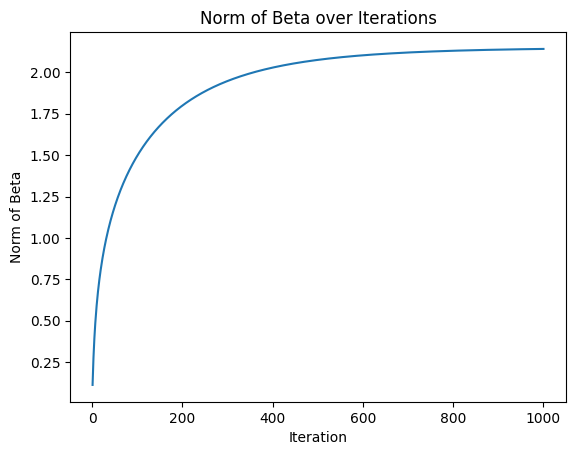

Zero-One Loss on test data: 0.018


In [31]:
# **(f) Rerunning the Code on Digits "6" and "8"**

# Extract digits "6" and "8" from training data
train_filter_68 = (y_train == 6) | (y_train == 8)
X_train_68 = X_train[train_filter_68.flatten()]
y_train_68 = y_train[train_filter_68].flatten()
# Convert labels to 0 and 1 (label "6" as 0, "8" as 1)
y_train_68 = (y_train_68 == 8).astype(int)

# Extract digits "6" and "8" from test data
test_filter_68 = (y_test == 6) | (y_test == 8)
X_test_68 = X_test[test_filter_68.flatten()]
y_test_68 = y_test[test_filter_68].flatten()
# Convert labels to 0 and 1
y_test_68 = (y_test_68 == 8).astype(int)

# Add intercept term
X_train_68 = np.hstack((np.ones((X_train_68.shape[0], 1)), X_train_68))
X_test_68 = np.hstack((np.ones((X_test_68.shape[0], 1)), X_test_68))

# Initialize beta
beta_68 = np.zeros(X_train_68.shape[1])

# Fine-tune hyperparameters
sigma_68 = 0.75     
epsilon_68 = 0.001
num_iterations_68 = 1000

beta_norm_list_68 = []

# Gradient Descent for Digits "6" and "8"
for iteration in range(num_iterations_68):
    z_68 = X_train_68.dot(beta_68)
    y_pred_68 = 1 / (1 + np.exp(-z_68))
    gradient_68 = X_train_68.T.dot(y_pred_68 - y_train_68) + beta_68 / sigma_68**2
    beta_68 -= epsilon_68 * gradient_68
    print(f"Iteration {iteration + 1}: Completed")
    beta_norm_68 = np.linalg.norm(beta_68)
    beta_norm_list_68.append(beta_norm_68)

# Plot the norm of beta over iterations
plt.plot(range(1, num_iterations_68 + 1), beta_norm_list_68)
plt.xlabel("Iteration")
plt.ylabel("Norm of Beta")
plt.title("Norm of Beta over Iterations")
plt.show()

# Prediction on test data
z_test_68 = X_test_68.dot(beta_68)
y_pred_test_prob_68 = 1 / (1 + np.exp(-z_test_68))
y_pred_test_68 = (y_pred_test_prob_68 >= 0.5).astype(int)

# Calculate zero-one loss using scikit-learn
zero_one_loss_68 = zero_one_loss(y_test_68, y_pred_test_68)
print(f"Zero-One Loss on test data: {zero_one_loss_68:.3f}")

In [32]:
# printing y_pred_test_68
print(y_pred_test_68)
# printing y_test_68
print(y_test_68)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1
 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1
 1]


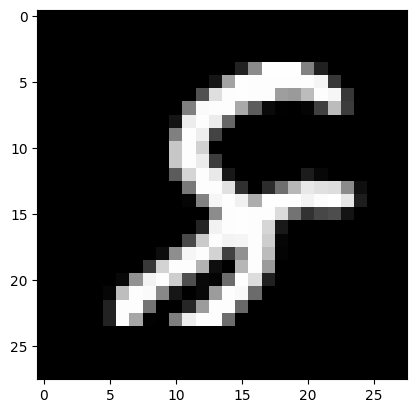

Predicted: 0, Actual: 1


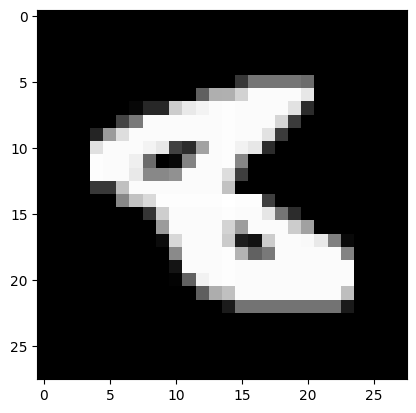

Predicted: 0, Actual: 1


In [33]:
# getting the index of the wrong predictions
wrong_pred = np.where(y_pred_test_68 != y_test_68)

# displaying the wrong predictions in a loop
for i in wrong_pred[0]:
    plt.imshow(X_test_68[i][1:].reshape(28,28), cmap='gray')
    plt.show()
    print(f"Predicted: {y_pred_test_68[i]}, Actual: {y_test_68[i]}")

#### in this case the zero one loss is 0.018 which is still good but not as good as the previous case, Different Hyperparameters have been used and we finally settled on sigma = 0.75 and epsilon = 0.001, But you can see that the misclassified samples are somewhat ambiguous and typically hard to classify than the other samples.

In [41]:
from sklearn.decomposition import PCA
import time

# Define the number of principal components to test
pcs = [10, 20, 30]

for pc in pcs:
    print(f"Number of Principal Components: {pc}")
    
    
    # Apply PCA to the training data
    pca = PCA(n_components=pc)
    pca.fit(X_train_01[:, 1:])  # Exclude the intercept term for PCA
    X_train_pca = pca.transform(X_train_01[:, 1:])
    X_test_pca = pca.transform(X_test_01[:, 1:])
    
    # Add intercept term back
    X_train_pca = np.hstack((np.ones((X_train_pca.shape[0], 1)), X_train_pca))
    X_test_pca = np.hstack((np.ones((X_test_pca.shape[0], 1)), X_test_pca))
    
    # Initialize beta
    beta_pca = np.zeros(X_train_pca.shape[1])
    
    # Set hyperparameters
    sigma_pca = 1.0
    epsilon_pca = 0.01
    num_iterations_pca = 1000
    
    # Start time measurement
    start_time = time.time()
    
    # Gradient Descent
    for iteration in range(num_iterations_pca):
        z_pca = X_train_pca.dot(beta_pca)
        y_pred_pca = 1 / (1 + np.exp(-z_pca))
        gradient_pca = X_train_pca.T.dot(y_pred_pca - y_train_01) + beta_pca / sigma_pca**2
        beta_pca -= epsilon_pca * gradient_pca
    
    # End time measurement
    end_time = time.time()
    time_consumption = end_time - start_time
    
    # Prediction on test data
    z_test_pca = X_test_pca.dot(beta_pca)
    y_pred_test_prob_pca = 1 / (1 + np.exp(-z_test_pca))
    y_pred_test_pca = (y_pred_test_prob_pca >= 0.5).astype(int)
    
    # Calculate zero-one loss using scikit-learn
    zero_one_loss_pca = zero_one_loss(y_test_01, y_pred_test_pca)
    
    
    print(f"Zero-One Loss on test data: {zero_one_loss_pca:.2f}%")
    #printing classification accuracy
    print(f"Classification Accuracy: {100 - zero_one_loss_pca:.2f}%")
    print(f"Time consumption: {time_consumption:.5f} seconds\n")


Number of Principal Components: 10
Zero-One Loss on test data: 0.00%
Classification Accuracy: 100.00%
Time consumption: 0.00495 seconds

Number of Principal Components: 20
Zero-One Loss on test data: 0.00%
Classification Accuracy: 100.00%
Time consumption: 0.00518 seconds

Number of Principal Components: 30
Zero-One Loss on test data: 0.00%
Classification Accuracy: 100.00%
Time consumption: 0.00522 seconds



#### As we can see using the different number of principal components as suggested doesn't make a difference at all in zero-one loss/classification accuracy, probably because of the very high performance of the model on the dataset and also the runtime difference is very low. I am not sure why that is the case. However If you run the code enough times you can see that the time consumption of the model with more principal components is higher than the model with fewer principal components.

In [35]:
from scipy.ndimage import rotate, shift

# Sample 10% of training data for digits "6" and "8"
num_samples_68 = X_train_68.shape[0]
indices_68 = np.arange(num_samples_68)
np.random.shuffle(indices_68)
sample_size = int(0.1 * num_samples_68)
sample_indices = indices_68[:sample_size]

X_train_68_small = X_train_68[sample_indices]
y_train_68_small = y_train_68[sample_indices]

# Reshape images to 28x28 (since we flattened earlier)
X_train_68_small_images = X_train_68_small[:, 1:].reshape(-1, 28, 28)  # Exclude intercept term

# Define augmentation function
def augment_data(images, labels, num_augmented_per_image):
    augmented_images = []
    augmented_labels = []
    for i in range(images.shape[0]):
        image = images[i]
        label = labels[i]
        for _ in range(num_augmented_per_image):
            # Random rotation angle between -15 and 15 degrees
            angle = np.random.uniform(-15, 15)
            # Random shifts between -5 and 5 pixels
            shift_x = np.random.uniform(-5, 5)
            shift_y = np.random.uniform(-5, 5)
            # Rotate image
            rotated_image = rotate(image, angle, reshape=False, mode='nearest')
            # Shift image
            shifted_image = shift(rotated_image, [shift_x, shift_y], mode='nearest')
            # Flatten and add intercept term
            flattened_image = shifted_image.flatten()
            augmented_image = np.hstack((1, flattened_image))
            augmented_images.append(augmented_image)
            augmented_labels.append(label)
    return np.array(augmented_images), np.array(augmented_labels)

# Augment data with different numbers of augmented images
augmented_times_list = [3, 5]

for augmented_times in augmented_times_list:
    print(f"Augmenting data {augmented_times} times per image")
    # Augment data
    X_augmented, y_augmented = augment_data(X_train_68_small_images, y_train_68_small, augmented_times)
    # Combine with original small dataset
    X_train_augmented = np.vstack((X_train_68_small, X_augmented))
    y_train_augmented = np.hstack((y_train_68_small, y_augmented))
    
    # Initialize beta
    beta_aug = np.zeros(X_train_augmented.shape[1])
    
    # Set hyperparameters
    sigma_aug = 0.5
    epsilon_aug = 0.005
    num_iterations_aug = 1000
    
    # Gradient Descent
    for iteration in range(num_iterations_aug):
        z_aug = X_train_augmented.dot(beta_aug)
        y_pred_aug = 1 / (1 + np.exp(-z_aug))
        gradient_aug = X_train_augmented.T.dot(y_pred_aug - y_train_augmented) + beta_aug / sigma_aug**2
        beta_aug -= epsilon_aug * gradient_aug
    
    # Prediction on test data
    z_test_aug = X_test_68.dot(beta_aug)
    y_pred_test_prob_aug = 1 / (1 + np.exp(-z_test_aug))
    y_pred_test_aug = (y_pred_test_prob_aug >= 0.5).astype(int)
    
    # Calculate zero-one loss
    zero_one_loss_aug = np.mean(y_pred_test_aug != y_test_68)
    print(f"Zero-One Loss on test data: {zero_one_loss_aug:.5f}")
    # printing classification accuracy
    print(f"Classification Accuracy: {100 - zero_one_loss_aug*100:.5f}%\n")


Augmenting data 3 times per image
Zero-One Loss on test data: 0.27679
Classification Accuracy: 72.32143%

Augmenting data 5 times per image
Zero-One Loss on test data: 0.16071
Classification Accuracy: 83.92857%



### As we can see that even though the zero one loss suffered considerably to our original prediction of 0.018 because we were only using 10% of the data, you can see that the dataset with 5 times augmentation has a better zero one loss/classification Accuracy than the dataset with 3 times augmentation. This proves that data augmentation is a good technique to improve the performance of the model. However if we run the model different times, the results may vary, since we are selecting the data randomly.

# End Of Assignment Solution

*programming assisted by Github Copilot and ChatGPT

### Now as an experiment, we will try to calculate the zero one loss for every digit with every other digit as the second class and display it as a heatmap.

In [36]:
# creating a function to take train  and test data and return the zero one loss
def get_zero_one_loss(X_train, y_train, X_test, y_test):
    # Initialize beta
    beta = np.zeros(X_train.shape[1])

    # Set hyperparameters
    sigma = 1.0
    epsilon = 0.01
    num_iterations = 1000

    # Gradient Descent
    for iteration in range(num_iterations):
        z = X_train.dot(beta)
        y_pred = 1 / (1 + np.exp(-z))
        gradient = X_train.T.dot(y_pred - y_train) + beta / sigma**2
        beta -= epsilon * gradient

    # Prediction on test data
    z_test = X_test.dot(beta)
    y_pred_test_prob = 1 / (1 + np.exp(-z_test))
    y_pred_test = (y_pred_test_prob >= 0.5).astype(int)

    # Calculate zero-one loss
    zero_one_loss = np.mean(y_pred_test != y_test)
    return zero_one_loss


In [37]:
# creating lists having X_train, y_train, X_test, y_test data for the digits 0 through 9
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

for i in range(10):
    # Extract digits from training data
    train_filter = (y_train == i)
    X_train_i = X_train[train_filter.flatten()]
    y_train_i = y_train[train_filter].flatten()

    # Extract digits from test data
    test_filter = (y_test == i)
    X_test_i = X_test[test_filter.flatten()]
    y_test_i = y_test[test_filter].flatten()

    # Add intercept term
    X_train_i = np.hstack((np.ones((X_train_i.shape[0], 1)), X_train_i))
    X_test_i = np.hstack((np.ones((X_test_i.shape[0], 1)), X_test_i))
    
    X_train_list.append(X_train_i)
    y_train_list.append(y_train_i)
    X_test_list.append(X_test_i)
    y_test_list.append(y_test_i)


In [38]:
# Calculating zero-one loss for each digit with every other digit as the second class
# Initialize zero-one loss matrix
zero_one_loss_matrix = np.zeros((10, 10))

# Calculate zero-one loss for each pair of digits
for i in range(10):
    for j in range(10):
        if i != j:
            # Combine data for two digits
            X_train_ij = np.vstack((X_train_list[i], X_train_list[j]))
            y_train_ij = np.hstack((np.zeros(X_train_list[i].shape[0]), np.ones(X_train_list[j].shape[0])))
            X_test_ij = np.vstack((X_test_list[i], X_test_list[j]))
            y_test_ij = np.hstack((np.zeros(X_test_list[i].shape[0]), np.ones(X_test_list[j].shape[0])))
            # Calculate zero-one loss
            zero_one_loss_ij = get_zero_one_loss(X_train_ij, y_train_ij, X_test_ij, y_test_ij)
            zero_one_loss_matrix[i, j] = zero_one_loss_ij

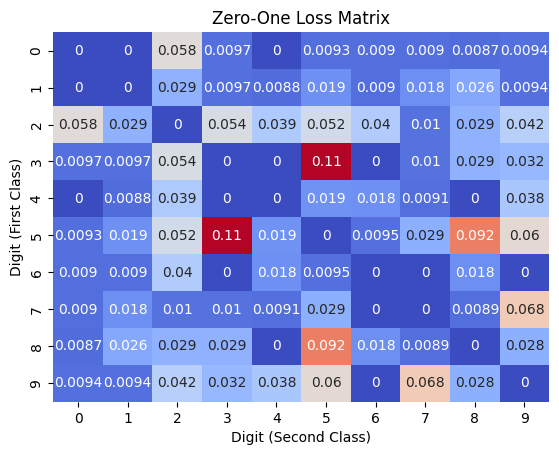

In [39]:
# showing the zero one loss matrix as a heatmap
import seaborn as sns
sns.heatmap(zero_one_loss_matrix, annot=True, cmap='coolwarm', cbar=False)
plt.xlabel("Digit (Second Class)")
plt.ylabel("Digit (First Class)")
plt.title("Zero-One Loss Matrix")
plt.show()

#### The heatmap displays some intriguing results with the worst classification performance in terms of zero-one loss being between digits 3 and 5. Many other inferences can be made from the heatmap, such as the performance of the model in distinguishing between different digits.